<a href="https://colab.research.google.com/github/LOKESHTEWATIA/WAY-TO-ML/blob/main/day_23_feature_scaling_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pasinduperera878/utilities")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utilities' dataset.
Path to dataset files: /kaggle/input/utilities


In [6]:
data = pd.read_csv('Utilities.csv')
data


,id,month,day,year,temp,kwh,ccf,thermsPerDay,billingDays,totalbill,gasbill,elecbill,notes,donate
0,1,1,28,2000,18,533,164,5.6,30,139.18,95.88,43.30,NaN,no
1,2,1,28,2002,23,581,210,6.6,32,174.45,127.86,46.59,NaN,no
2,3,1,28,2004,15,594,242,8.1,30,262.81,216.89,47.37,NaN,no
3,4,1,27,2005,15,891,224,7.5,30,294.96,223.92,71.04,NaN,no
4,5,1,29,2006,30,927,144,4.5,32,282.25,193.84,90.28,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,113,12,28,2005,21,931,176,5.8,31,324.52,240.90,83.62,NaN,no
113,114,12,27,2006,30,720,140,4.5,31,229.40,159.08,70.32,NaN,yes
114,115,12,27,2007,18,980,182,6.0,31,296.10,194.91,101.19,NaN,no
115,116,12,29,2008,18,1205,199,5.8,35,332.09,209.21,122.88,NaN,yes


In [7]:
data[['year','temp','totalbill']]

,year,temp,totalbill
0,2000,18,139.18
1,2002,23,174.45
2,2004,15,262.81
3,2005,15,294.96
4,2006,30,282.25
...,...,...,...
112,2005,21,324.52
113,2006,30,229.40
114,2007,18,296.10
115,2008,18,332.09


In [8]:
data.describe()

,id,month,day,year,temp,kwh,ccf,thermsPerDay,billingDays,totalbill,gasbill,elecbill
count,117.000000,117.000000,117.000000,117.000000,117.00000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,59.000000,6.564103,26.589744,2004.854701,48.65812,750.965812,83.444444,2.746154,30.290598,157.744701,81.244274,76.669658
std,33.919021,3.419983,1.757515,3.035040,20.56787,202.107770,74.388014,2.442672,2.629605,69.070240,66.529159,25.338237
min,1.000000,1.000000,23.000000,1999.000000,9.00000,160.000000,0.000000,0.000000,10.000000,31.550000,3.420000,17.430000
25%,30.000000,4.000000,26.000000,2002.000000,30.00000,583.000000,16.000000,0.500000,29.000000,106.650000,23.420000,53.560000
50%,59.000000,7.000000,26.000000,2005.000000,51.00000,790.000000,60.000000,2.000000,30.000000,134.500000,55.740000,78.820000
75%,88.000000,9.000000,28.000000,2007.000000,69.00000,893.000000,144.000000,4.700000,32.000000,192.670000,124.180000,94.510000
max,117.000000,12.000000,36.000000,2010.000000,78.00000,1213.000000,242.000000,8.100000,36.000000,332.090000,240.900000,152.200000


<Axes: xlabel='temp', ylabel='Density'>

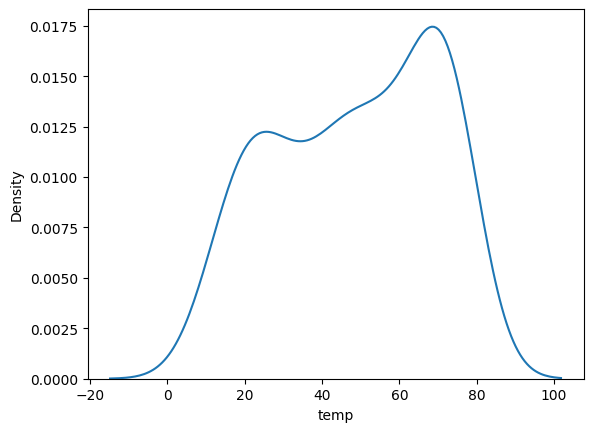

In [9]:
sns.kdeplot(data['temp'])

In [10]:
sns.scatterplot(data['totalbill'],data['temp'])


TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 were given

In [11]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('notes',axis = 1) ,data['year'], test_size=0.33, random_state=0)

X_train.shape ,y_train.shape

((78, 13), (78,))

In [17]:
X_train = X_train.drop(['donate'], axis=1)
X_test = X_test.drop(['donate'], axis=1)

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [38]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=X_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=X_test.columns)

In [39]:
import numpy as np
np.round(X_train.describe(), 1)

,id,month,day,year,temp,kwh,ccf,thermsPerDay,billingDays,totalbill,gasbill,elecbill
count,78.0,78.0,78.0,78.0,78.0,78.0,78.0,78.0,78.0,78.0,78.0,78.0
mean,59.0,6.6,26.7,2004.8,50.1,751.8,77.5,2.5,30.4,151.7,75.6,77.1
std,32.9,3.3,1.8,3.1,19.5,198.9,68.9,2.2,2.9,64.0,62.8,24.8
min,1.0,1.0,24.0,1999.0,13.0,160.0,0.0,0.0,10.0,31.6,3.4,17.4
25%,32.2,4.0,26.0,2002.0,34.0,591.5,16.0,0.5,29.0,106.4,22.9,55.5
50%,57.0,6.0,26.5,2005.0,52.5,784.0,60.5,2.0,30.0,132.9,54.7,79.1
75%,84.8,9.0,28.0,2007.0,69.0,906.0,136.8,4.5,32.0,172.3,111.2,94.8
max,116.0,12.0,36.0,2010.0,78.0,1205.0,216.0,7.6,36.0,332.1,224.2,130.8


In [40]:
np.round(x_train_scaled.describe(), 1)

,id,month,day,year,temp,kwh,ccf,thermsPerDay,billingDays,totalbill,gasbill,elecbill
count,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0
mean,0.3,0.2,0.5,0.3,0.4,0.4,0.5,0.6,0.5,0.5,0.4,0.3
std,0.4,0.3,0.4,0.4,0.4,0.4,0.4,0.4,0.2,0.3,0.4,0.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
50%,0.0,0.0,0.7,0.0,0.5,0.5,0.5,0.8,0.5,0.5,0.1,0.5
75%,0.5,0.5,0.9,0.7,0.8,0.8,0.9,0.9,0.5,0.5,0.5,0.5
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [41]:
data2 = pd.read_csv('llm_labels_full.csv')
data2

,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,0.50,0.50,0.95,0.50,0.95,0.50,0.50,0.92,0.50,0.50,0.50,0.50
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,0.50,0.50,0.68,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,0.05,0.05,0.10,0.03,0.88,0.05,0.84,0.05,0.50,0.03,0.05,0.05
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.02,0.50,0.50,0.02,0.02
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,0.03,0.82,0.82,0.03,0.82,0.82,0.97,0.08,0.50,0.02,0.50,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,1.2.826.0.1.3680043.8.498.99880021280666757817...,0.10,0.05,0.98,0.96,0.94,0.84,0.90,0.82,0.92,0.95,0.05,0.05
4403,1.2.826.0.1.3680043.8.498.99881620336512626242...,0.99,0.05,0.05,0.05,0.50,0.50,0.50,0.50,0.50,0.50,0.97,0.50
4404,1.2.826.0.1.3680043.8.498.99926624968240681772...,0.05,0.05,0.84,0.94,0.50,0.50,0.80,0.82,0.50,0.50,0.50,0.50
4405,1.2.826.0.1.3680043.8.498.99939100657291954890...,0.05,0.05,0.10,0.10,0.50,0.50,0.70,0.85,0.50,0.50,0.05,0.50


<Axes: xlabel='Medial OA', ylabel='Density'>

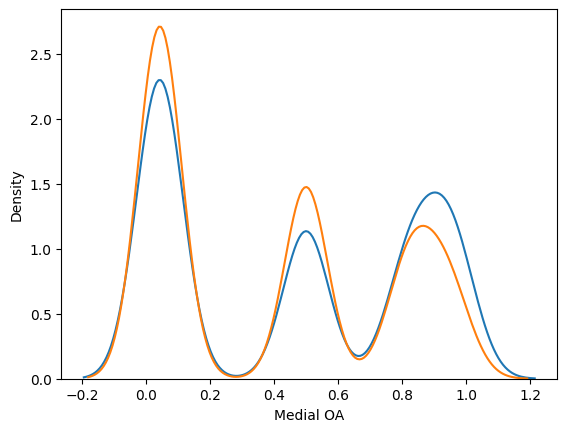

In [42]:
sns.kdeplot(data2['Medial OA'])
sns.kdeplot(data2['Lateral OA'])

In [57]:
from sklearn.model_selection import train_test_split
xx_train,xx_test,y_train,y_test = train_test_split(data2.drop('StudyInstanceUID',axis = 1) ,data2['StudyInstanceUID'], test_size=0.33, random_state=0)

In [58]:
xx_train.shape,y_train.shape

((2952, 12), (2952,))

In [59]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
xx_train_scaled = scaler.fit_transform(xx_train)
xx_test_scaled = scaler.transform(xx_test)

In [65]:
xx_train_scaled

array([[0.03061224, 0.03092784, 0.03092784, ..., 0.49484536, 0.03092784,
        0.03092784],
       [0.03061224, 0.03092784, 0.03092784, ..., 0.03092784, 0.03092784,
        0.03092784],
       [0.03061224, 0.03092784, 0.03092784, ..., 0.03092784, 0.03092784,
        0.03092784],
       ...,
       [0.98979592, 0.01030928, 0.98969072, ..., 0.03092784, 0.01030928,
        0.01030928],
       [0.48979592, 0.95876289, 0.49484536, ..., 0.49484536, 0.49484536,
        0.49484536],
       [0.03061224, 0.03092784, 0.98969072, ..., 0.49484536, 0.03092784,
        0.03092784]])

In [66]:
pd.DataFrame(xx_train_scaled, columns=xx_train.columns)
pd.DataFrame(xx_test_scaled, columns=xx_test.columns)

,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,0.857143,0.030928,0.938144,0.030928,0.846939,0.494845,0.494845,0.928571,0.5000,0.948454,0.030928,0.030928
1,0.030612,0.030928,0.948454,0.845361,0.489796,0.494845,0.494845,0.826531,0.5000,0.494845,0.030928,0.494845
2,0.030612,0.494845,0.030928,0.030928,0.030612,0.030928,0.030928,0.948980,0.5000,0.824742,0.824742,0.494845
3,0.081633,0.030928,0.886598,0.030928,0.918367,0.824742,0.494845,0.785714,0.5000,0.494845,0.824742,0.494845
4,0.030612,0.030928,0.958763,0.030928,0.795918,0.030928,0.030928,0.040816,0.5000,0.030928,0.030928,0.030928
...,...,...,...,...,...,...,...,...,...,...,...,...
1450,0.030612,0.030928,0.701031,0.030928,0.030612,0.030928,0.989691,0.040816,0.5000,0.030928,0.030928,0.030928
1451,0.795918,0.030928,0.948454,0.030928,0.979592,0.824742,0.907216,0.948980,0.5000,0.494845,0.030928,0.030928
1452,0.030612,0.030928,0.989691,0.030928,0.877551,0.030928,0.927835,0.040816,0.5000,0.030928,0.030928,0.030928
1453,0.010204,0.010309,0.010309,0.010309,0.010204,0.010309,0.010309,0.020408,0.5000,0.494845,0.010309,0.494845


In [68]:
pd.round(x_train_scaled.describe(), 1)

AttributeError: module 'pandas' has no attribute 'round'

In [63]:
np.round(xx_train.describe(), 1)

,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
count,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0,2952.0
mean,0.3,0.2,0.5,0.3,0.5,0.4,0.5,0.6,0.5,0.5,0.4,0.3
std,0.4,0.3,0.4,0.4,0.4,0.4,0.4,0.4,0.2,0.3,0.4,0.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
50%,0.0,0.0,0.7,0.0,0.5,0.5,0.5,0.8,0.5,0.5,0.1,0.5
75%,0.5,0.5,0.9,0.7,0.8,0.8,0.9,0.9,0.5,0.5,0.5,0.5
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [64]:
xx_train.desribe()

AttributeError: 'DataFrame' object has no attribute 'desribe'